In [1]:
# The line below allows to print all the outputs of a cell instead of only the last one
%config InteractiveShell.ast_node_interactivity = "all"
import os
import pathlib
import sys

import pandas as pd
import yaml

In [5]:
from_script = True

print(f"WARNING: This notebook is set with from_script = {from_script}.")

if from_script:
    # Get the path of the notebook config file from the environment variable
    path_config_notebook = os.environ["PATH_YAML_CONFIG"]
    # Load the notebook config file
    with open(path_config_notebook, "r") as file:
        dict_config_notebook = yaml.safe_load(file)
        print("The dict_config_notebook is:")
        print(dict_config_notebook)
    ID_XP_DATASET = dict_config_notebook["id_xp_dataset"]
    ID_XP = dict_config_notebook["id_xp"]
    PATH_PROJECT = pathlib.Path(dict_config_notebook["path_project"])
    DICT_FILTERS = dict_config_notebook.get("dict_filters", None)
    NAME_MLFLOW_STORE = dict_config_notebook.get(
        "name_mlflow_store", "mlruns_ruche_downloaded"
    )
else:
    ID_XP_DATASET = 21
    ID_XP = 24
    PATH_PROJECT = pathlib.Path(
        "/home/hosseinkhan/Documents/work/phd/git_repositories/control_dde"
    )
    DICT_FILTERS = {
        "env_name": ["cylinder"],
        "env_params_max_control": [0.0],
        "env_params_reynolds": [120.0, 90.0],
    }

    NAME_MLFLOW_STORE = "mlruns_ruche_downloaded"

# Add the path of the project to the sys.path in order to import
# the modules in the src folder
sys.path.insert(0, os.path.abspath(PATH_PROJECT))

# Define the paths
path_mlruns = pathlib.Path(f"{PATH_PROJECT}/data/{NAME_MLFLOW_STORE}")
path_experiment_dataset = pathlib.Path(f"{path_mlruns}/{ID_XP_DATASET}")
path_experiment = pathlib.Path(f"{path_mlruns}/{ID_XP}")
# Get all folder in the mlruns/id_xp directory except the folder 'tags'
# using pathlib and iter dir
list_id_hash = [
    path.name
    for path in path_experiment.iterdir()
    if path.is_dir() and path.name != "tags"
]
list_id_hash_dataset = [
    path.name
    for path in path_experiment_dataset.iterdir()
    if path.is_dir() and path.name != "tags"
]

print(f"Number of runs in the dataset: {len(list_id_hash_dataset)} \n")
print(f"Number of runs: {len(list_id_hash)} \n")
print(f"XP id dataset: {ID_XP_DATASET} \n")
print(f"XP id: {ID_XP} \n")

nested_dict_config_dataset = {}
nested_dict_config = {}
list_df_config_flattened_dataset = []
list_df_config_flattened = []


def check_xp_lifecycle(path_file: pathlib.Path):
    if not path_file.exists():
        raise FileNotFoundError(f"The file {path_file} does not exist.")
    if not path_file.is_file():
        raise FileNotFoundError(f"The path {path_file} is not a file.")
    # Load the yaml file
    with open(path_file, "r") as _file:
        dict_temp = yaml.safe_load(_file)
    # Check the lifecycle key
    assert dict_temp.get("lifecycle_stage") == "active", "The experiment is not active."


# Verify all experiments are done on the same environment:
path_xp = f"{path_mlruns}/{ID_XP}"
for name_id in list_id_hash:
    # Check file lifecycle
    list_glob_xp_metadata = list(pathlib.Path(f"{path_xp}/{name_id}").glob("meta.yaml"))
    assert len(list_glob_xp_metadata) != 0, "No metadata file in the directory."
    assert (
        len(list_glob_xp_metadata) == 1
    ), "More than one metadata file in the directory."
    check_xp_lifecycle(list_glob_xp_metadata[0])

    # Get the config file
    list_glob_config = list(
        pathlib.Path(f"{path_xp}/{name_id}/artifacts").glob("./config/*.yaml")
    )
    assert len(list_glob_config) != 0, "No config file in the directory."
    assert len(list_glob_config) == 1, "More than one config file in the directory."

    name_config_file = list_glob_config[0].name
    # Check if the file is a yaml file
    assert name_config_file.endswith(".yaml"), "File is not a yaml file."

    path_run_config_yaml = list_glob_config[0]
    with open(path_run_config_yaml, "r") as file:
        # Get the config file as a dictionary
        dict_config_temp = yaml.safe_load(file)
        # Add the config file to the nested dictionary
        nested_dict_config[name_id] = dict_config_temp
        # Flatten the config file for easier check
        list_df_config_flattened.append(pd.json_normalize(dict_config_temp, sep="_"))
    del dict_config_temp

path_xp_dataset = f"{path_mlruns}/{ID_XP_DATASET}"
for name_id in list_id_hash_dataset:
    list_glob_config = list(
        pathlib.Path(f"{path_xp_dataset}/{name_id}/generated_data").glob(
            "./config/*.yaml"
        )
    )
    assert len(list_glob_config) != 0, "No config file in the directory."
    assert len(list_glob_config) == 1, "More than one config file in the directory."

    name_config_file = list_glob_config[0].name
    # Check if the file is a yaml file
    assert name_config_file.endswith(".yaml"), "File is not a yaml file."

    path_run_config_yaml = list_glob_config[0]
    with open(path_run_config_yaml, "r") as file:
        # Get the config file as a dictionary
        dict_config_temp = yaml.safe_load(file)
        # Add the config file to the nested dictionary
        nested_dict_config_dataset[name_id] = dict_config_temp
        # Flatten the config file for easier check
        list_df_config_flattened_dataset.append(
            pd.json_normalize(dict_config_temp, sep="_")
        )
    del dict_config_temp

Number of runs in the dataset: 22 

Number of runs: 176 

XP id dataset: 21 

XP id: 24 



### DataFrames generation

#### DataFrame: Training config

In [6]:
df_trainining_config = pd.concat(
    [
        df_config_flattened.assign(training_id=name_id)
        for name_id, df_config_flattened in zip(list_id_hash, list_df_config_flattened)
    ]
).set_index("training_id")

df_trainining_config.head(10)

,mlflow_experiment_name,seed,data_normaliser_name,data_path_data_folder,model_name,model_params_activation,model_params_delay_exponential_dist_param,model_params_depth,model_params_dropout,model_params_final_activation,...,trainer_name,trainer_params_bool_discretize_then_optimize,trainer_params_lr_final,trainer_params_lr_init,trainer_params_max_epochs,trainer_params_name_node_interface,trainer_params_pct_trajectory_size,trainer_params_rate_test_set_size,trainer_params_solver,model_params_n_delays
training_id,,,,,,,,,,,,,,,,,,,,,
f49eee38fc7f49e2b7b99d7880530f80,2024_11_27_training_00h_04m,0,standard_normal,data/mlruns/21/331afa8c845f4bc295b05a7d4ec716e...,ncde,relu,5.0,2,0,identity,...,ncde,True,0.0005,0.0005,4000,torchdde,1.0,0.1,rk4,NaN
0abed15ee28c44e4ae29149d1431efa0,2024_11_27_training_00h_04m,0,standard_normal,data/mlruns/21/4e27a8e7a9c24b70acf9ba88d538cfc...,node,relu,5.0,2,0,identity,...,node,True,0.0005,0.0005,4000,torchdde,1.0,0.1,rk4,NaN
5fdfd5942e6e4c80a2a75e4eae5131e5,2024_11_27_training_00h_04m,0,standard_normal,data/mlruns/21/4bbd8db9115d46c1bf2805c7718ac1c...,ndde,relu,5.0,2,0,identity,...,ndde,True,0.0005,0.0005,4000,torchdde,1.0,0.1,rk4,1.0
da38baa85d514f79955666a12c97e2e4,2024_11_27_training_00h_04m,1,standard_normal,data/mlruns/21/30cf92b2bedb4adf92c965923008947...,ncde,relu,5.0,2,0,identity,...,ncde,True,0.0005,0.0005,4000,torchdde,1.0,0.1,rk4,NaN
4459de875178471c9166160b89154651,2024_11_27_training_00h_04m,1,standard_normal,data/mlruns/21/ea32766566804a7e94de4ec18042b53...,node,relu,5.0,2,0,identity,...,node,True,0.0005,0.0005,4000,torchdde,1.0,0.1,rk4,NaN
830c48fa6f874d9989a8d032c7e9009f,2024_11_27_training_00h_04m,0,standard_normal,data/mlruns/21/cacb5c52a3d74da296747074fd5fb9b...,ndde,relu,5.0,2,0,identity,...,ndde,True,0.0005,0.0005,4000,torchdde,1.0,0.1,rk4,1.0
40de98773aea425dbd2361b480b316f6,2024_11_27_training_00h_04m,1,standard_normal,data/mlruns/21/a5b3d73e8ef34096ad8444bf8bbaa09...,node,relu,5.0,2,0,identity,...,node,True,0.0005,0.0005,4000,torchdde,1.0,0.1,rk4,NaN
c529fe1fa573493383032a639772d97b,2024_11_27_training_00h_04m,0,standard_normal,data/mlruns/21/ea32766566804a7e94de4ec18042b53...,node,relu,5.0,2,0,identity,...,node,True,0.0005,0.0005,4000,torchdde,1.0,0.1,rk4,NaN
1ebdbac8b92c4b6e9ce4ff451a4aabc8,2024_11_27_training_00h_04m,0,standard_normal,data/mlruns/21/9d62461e67724e92a55a7b24844fd96...,ndde,relu,5.0,2,0,identity,...,ndde,True,0.0005,0.0005,4000,torchdde,1.0,0.1,rk4,1.0


#### DataFrame: Dataset config

In [7]:
df_dataset_config = pd.concat(
    [
        df_config_flattened.assign(dataset_id=name_id)
        for name_id, df_config_flattened in zip(
            list_id_hash_dataset, list_df_config_flattened_dataset
        )
    ]
).set_index("dataset_id")
df_dataset_config.head(10)

,mlflow_experiment_name,seed,data_control_type,data_num_steps,data_num_trajectories,data_type,env_name,env_params_delay_observation,env_params_dict_solver_dt,env_params_dict_solver_name,env_params_dict_solver_order,env_params_dict_solver_stabilization,env_params_dt,env_params_log_callback_interval,env_params_max_control,env_params_mesh,env_params_name_flow,env_params_paraview_callback_interval,env_params_reynolds
dataset_id,,,,,,,,,,,,,,,,,,,
7b9425923c424262bb6fe6663bbc2e95,2024_11_25_training_data_20h_58m,0,uniform,200,40,unique_trajectory_divided,cavity,0.0,0.001,semi_implicit_bdf,2,none,0.01,1000,0.01,coarse,cavity,1000,7500
012c4b89a6674b259c01f430b23e6dfd,2024_11_25_training_data_20h_58m,0,uniform,200,400,unique_trajectory_divided,cylinder,0.0,0.010,semi_implicit_bdf,2,none,0.01,100,0.00,coarse,cylinder,100,90
ad0bd86499934c3ba07ec7de74988282,2024_11_25_training_data_20h_58m,0,uniform,200,400,unique_trajectory_divided,cylinder,0.0,0.010,semi_implicit_bdf,2,none,0.01,100,0.01,coarse,cylinder,100,105
43cefeefc71e4c368902a04b6cde7aa6,2024_11_25_training_data_20h_58m,0,uniform,200,40,unique_trajectory_divided,cavity,0.0,0.001,semi_implicit_bdf,2,none,0.01,1000,0.00,coarse,cavity,1000,7500
f48fb37d20ea48f3a3f7141bcf751363,2024_11_25_training_data_20h_58m,0,uniform,200,40,unique_trajectory_divided,cavity,0.0,0.001,semi_implicit_bdf,2,none,0.01,1000,0.00,coarse,cavity,1000,5000
a5b3d73e8ef34096ad8444bf8bbaa098,2024_11_25_training_data_20h_58m,0,uniform,200,40,unique_trajectory_divided,cavity,0.0,0.001,semi_implicit_bdf,2,none,0.01,1000,0.01,coarse,cavity,1000,500
3cf77ebaf98245e4a10d7f7edcf37ea8,2024_11_25_training_data_20h_58m,0,uniform,200,400,unique_trajectory_divided,pinball,0.0,0.010,semi_implicit_bdf,2,none,0.01,100,0.00,coarse,pinball,100,105
ea32766566804a7e94de4ec18042b537,2024_11_25_training_data_20h_58m,0,uniform,200,400,unique_trajectory_divided,cylinder,0.0,0.010,semi_implicit_bdf,2,none,0.01,100,0.00,coarse,cylinder,100,105
e00c838399ad4f31be9ad1f3a33e26df,2024_11_25_training_data_20h_58m,0,uniform,200,40,unique_trajectory_divided,cavity,0.0,0.001,semi_implicit_bdf,2,none,0.01,1000,0.01,coarse,cavity,1000,5000


In [8]:
# Filtering function based on the DICT_FILTERS
def filter_dataframe(df: pd.DataFrame):
    mask = pd.Series([True] * len(df), index=df.index)
    if DICT_FILTERS is None:
        return mask
    else:
        for key, list_values in DICT_FILTERS.items():
            if key in df.columns:
                mask = mask & df[key].isin(list_values)
            else:
                print(f"Warning: The key {key} is not in the config file.")
    return mask


df_training_dataset_merged = (
    df_trainining_config.assign(
        dataset_id=lambda x: x.data_path_data_folder.str.extract(
            rf"{ID_XP_DATASET}/(.*?)/generated_data"
        )
    )
    .join(df_dataset_config, on="dataset_id", rsuffix="_dataset")
    .fillna({"model_params_n_delays": 0.0})
    .drop(columns=["data_path_data_folder"])
    .loc[lambda df: filter_dataframe(df)]
)
df_training_dataset_merged

,mlflow_experiment_name,seed,data_normaliser_name,model_name,model_params_activation,model_params_delay_exponential_dist_param,model_params_depth,model_params_dropout,model_params_final_activation,model_params_width_size,...,env_params_dict_solver_name,env_params_dict_solver_order,env_params_dict_solver_stabilization,env_params_dt,env_params_log_callback_interval,env_params_max_control,env_params_mesh,env_params_name_flow,env_params_paraview_callback_interval,env_params_reynolds
training_id,,,,,,,,,,,,,,,,,,,,,
830c48fa6f874d9989a8d032c7e9009f,2024_11_27_training_00h_04m,0,standard_normal,ndde,relu,5.0,2,0,identity,64,...,semi_implicit_bdf,2,none,0.01,100,0.0,coarse,cylinder,100,120
c26dd64706334340a840f421d7a995dc,2024_11_27_training_00h_04m,1,standard_normal,node,relu,5.0,2,0,identity,64,...,semi_implicit_bdf,2,none,0.01,100,0.0,coarse,cylinder,100,90
6e12ee4af8c5492487a35adaed03d876,2024_11_27_training_00h_04m,1,standard_normal,ncdde,relu,5.0,2,0,identity,64,...,semi_implicit_bdf,2,none,0.01,100,0.0,coarse,cylinder,100,90
47ad805accce4519af72581a379435b4,2024_11_27_training_00h_04m,0,standard_normal,ncde,relu,5.0,2,0,identity,64,...,semi_implicit_bdf,2,none,0.01,100,0.0,coarse,cylinder,100,120
3b17acdf94104d1a86a515124c4c32ed,2024_11_27_training_00h_04m,1,standard_normal,ncde,relu,5.0,2,0,identity,64,...,semi_implicit_bdf,2,none,0.01,100,0.0,coarse,cylinder,100,120
ca2c6e16ca264ba19663f35c10323c5d,2024_11_27_training_00h_04m,1,standard_normal,node,relu,5.0,2,0,identity,64,...,semi_implicit_bdf,2,none,0.01,100,0.0,coarse,cylinder,100,120
fa3979d35849421db77b27d4207b4a1b,2024_11_27_training_00h_04m,0,standard_normal,node,relu,5.0,2,0,identity,64,...,semi_implicit_bdf,2,none,0.01,100,0.0,coarse,cylinder,100,120
863670e175e44d17b359f72de1bf363b,2024_11_27_training_00h_04m,1,standard_normal,ndde,relu,5.0,2,0,identity,64,...,semi_implicit_bdf,2,none,0.01,100,0.0,coarse,cylinder,100,90
f85f98d5d83843e9b0c9ac49af73dbdb,2024_11_27_training_00h_04m,0,standard_normal,ncde,relu,5.0,2,0,identity,64,...,semi_implicit_bdf,2,none,0.01,100,0.0,coarse,cylinder,100,90


In [9]:
# Print unique values of df_training_dataset_merged for each column
# if the number of unique values is more than 1
for column in df_training_dataset_merged.columns:
    if df_training_dataset_merged[column].nunique() > 1:
        print(f"{column}: {df_training_dataset_merged[column].unique()}")

seed: [0 1]
model_name: ['ndde' 'node' 'ncdde' 'ncde']
trainer_name: ['ndde' 'node' 'ncdde' 'ncde']
model_params_n_delays: [1. 0.]
dataset_id: ['cacb5c52a3d74da296747074fd5fb9b2' '012c4b89a6674b259c01f430b23e6dfd']
env_params_reynolds: [120  90]


ID: 830c48fa6f874d9989a8d032c7e9009f
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           0
data_normaliser_name                                             standard_normal
model_name                                                                  ndde
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                                ndde
trainer_params_bool_discretize_then_optimize                            

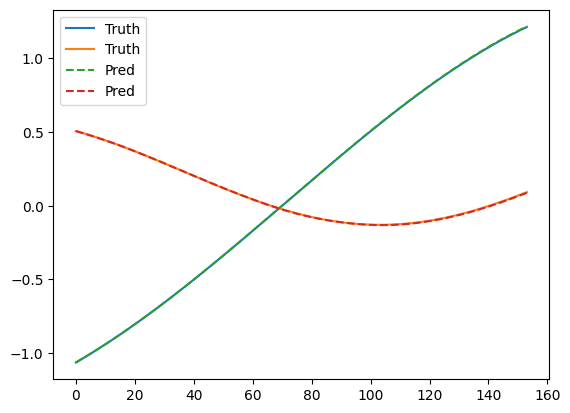



ID: c26dd64706334340a840f421d7a995dc
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           1
data_normaliser_name                                             standard_normal
model_name                                                                  node
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                                node
trainer_params_bool_discretize_then_optimize                          

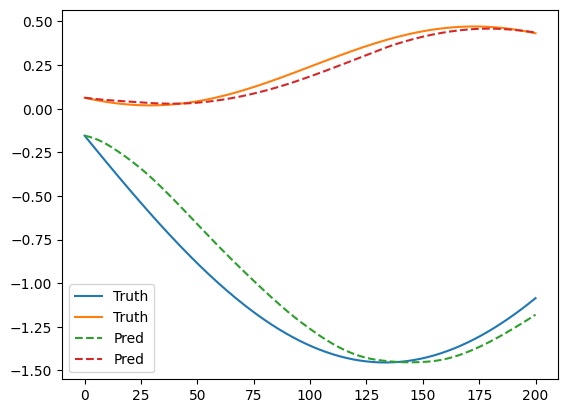



ID: 6e12ee4af8c5492487a35adaed03d876
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           1
data_normaliser_name                                             standard_normal
model_name                                                                 ncdde
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                               ncdde
trainer_params_bool_discretize_then_optimize                          

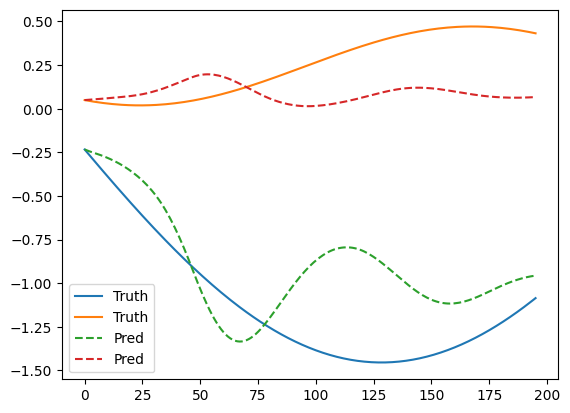



ID: 47ad805accce4519af72581a379435b4
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           0
data_normaliser_name                                             standard_normal
model_name                                                                  ncde
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                                ncde
trainer_params_bool_discretize_then_optimize                          

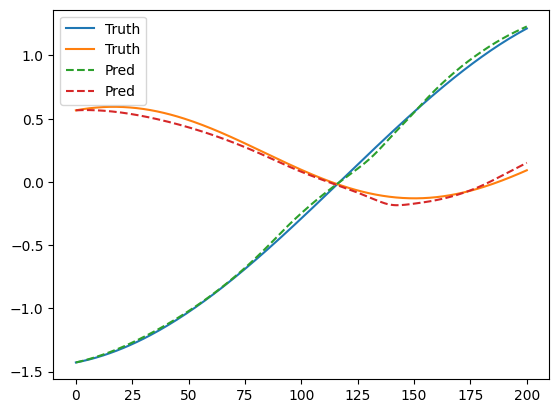



ID: 3b17acdf94104d1a86a515124c4c32ed
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           1
data_normaliser_name                                             standard_normal
model_name                                                                  ncde
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                                ncde
trainer_params_bool_discretize_then_optimize                          

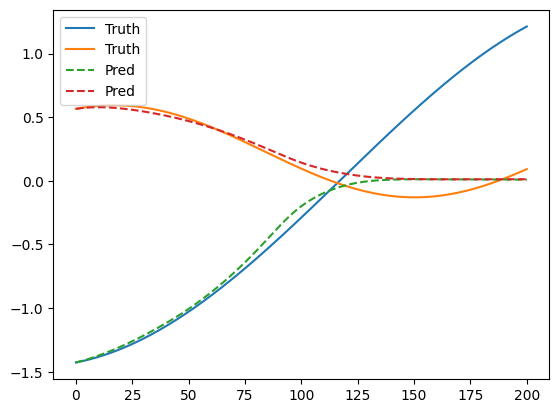



ID: ca2c6e16ca264ba19663f35c10323c5d
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           1
data_normaliser_name                                             standard_normal
model_name                                                                  node
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                                node
trainer_params_bool_discretize_then_optimize                          

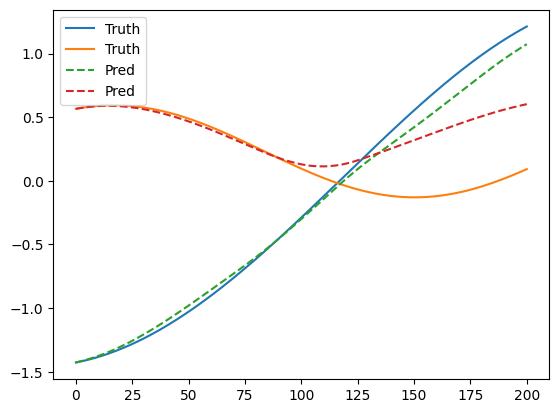



ID: fa3979d35849421db77b27d4207b4a1b
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           0
data_normaliser_name                                             standard_normal
model_name                                                                  node
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                                node
trainer_params_bool_discretize_then_optimize                          

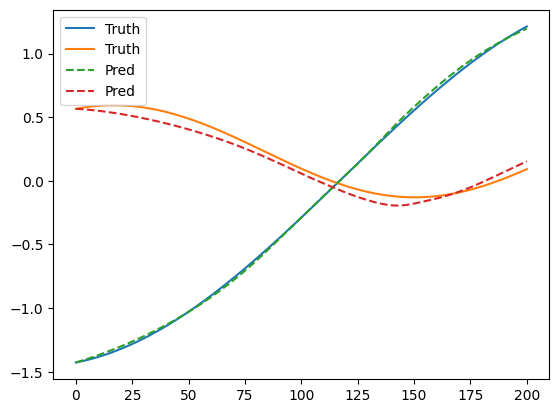



ID: 863670e175e44d17b359f72de1bf363b
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           1
data_normaliser_name                                             standard_normal
model_name                                                                  ndde
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                                ndde
trainer_params_bool_discretize_then_optimize                          

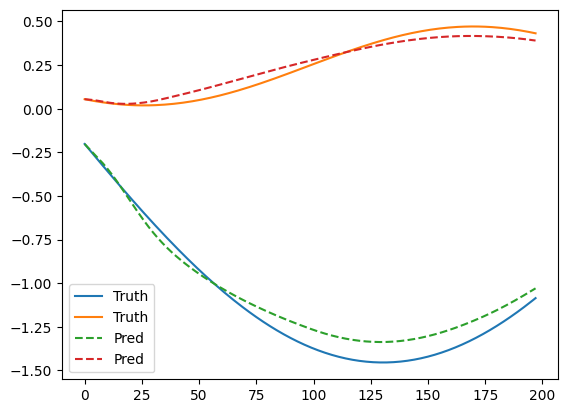



ID: f85f98d5d83843e9b0c9ac49af73dbdb
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           0
data_normaliser_name                                             standard_normal
model_name                                                                  ncde
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                                ncde
trainer_params_bool_discretize_then_optimize                          

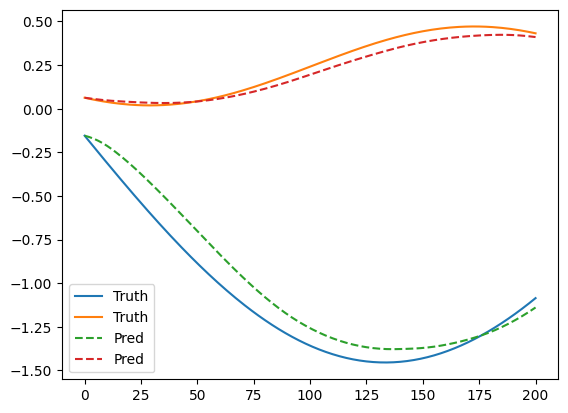



ID: 3c1ae00b47bf466ca3badcb046a3cbb4
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           0
data_normaliser_name                                             standard_normal
model_name                                                                 ncdde
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                               ncdde
trainer_params_bool_discretize_then_optimize                          

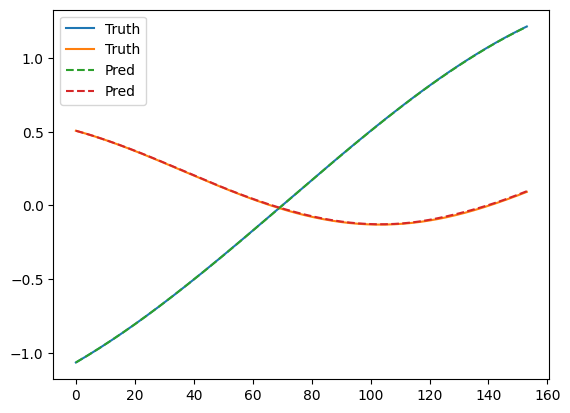



ID: fdcc15726c764b70a08f5400d4264a45
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           0
data_normaliser_name                                             standard_normal
model_name                                                                  ndde
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                                ndde
trainer_params_bool_discretize_then_optimize                          

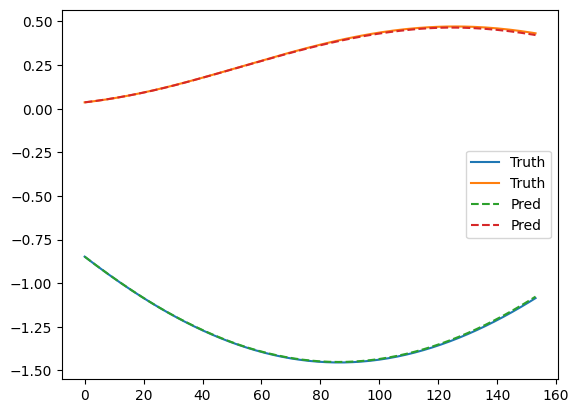



ID: b33cb60922c84370a5c6fca47da8dee6
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           1
data_normaliser_name                                             standard_normal
model_name                                                                  ncde
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                                ncde
trainer_params_bool_discretize_then_optimize                          

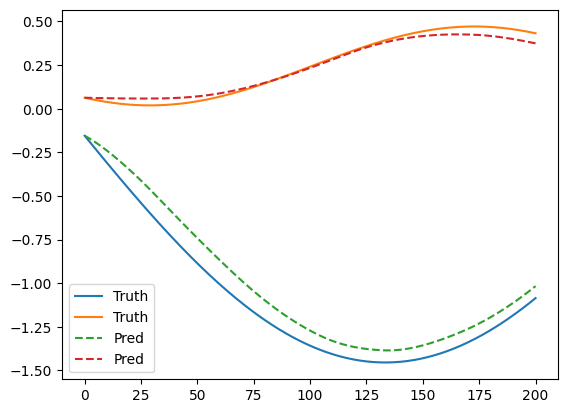



ID: bed31abf3f0d4498879e8c3d617b93d3
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           1
data_normaliser_name                                             standard_normal
model_name                                                                 ncdde
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                               ncdde
trainer_params_bool_discretize_then_optimize                          

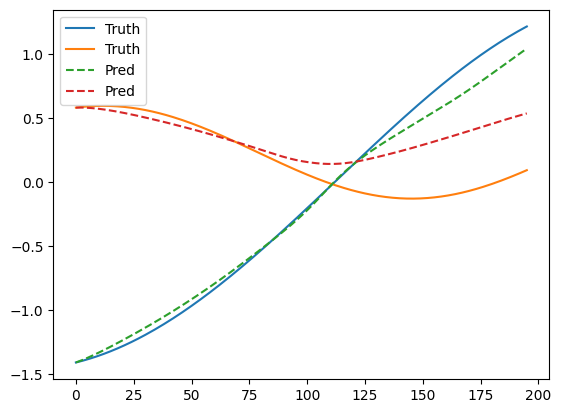



ID: 2d8808d002604e068461f64998ca2c4c
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           0
data_normaliser_name                                             standard_normal
model_name                                                                  node
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                                node
trainer_params_bool_discretize_then_optimize                          

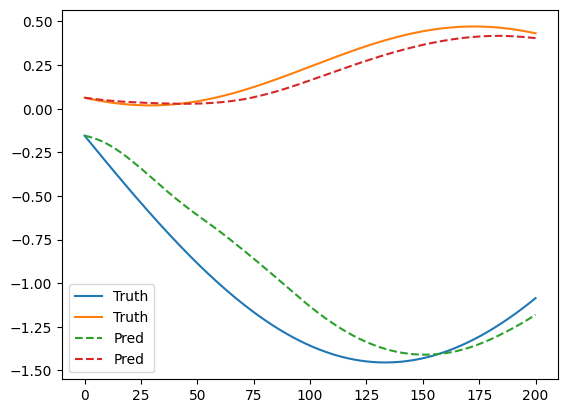



ID: 38872af040f244b1994ae8292869c703
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           0
data_normaliser_name                                             standard_normal
model_name                                                                 ncdde
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                               ncdde
trainer_params_bool_discretize_then_optimize                          

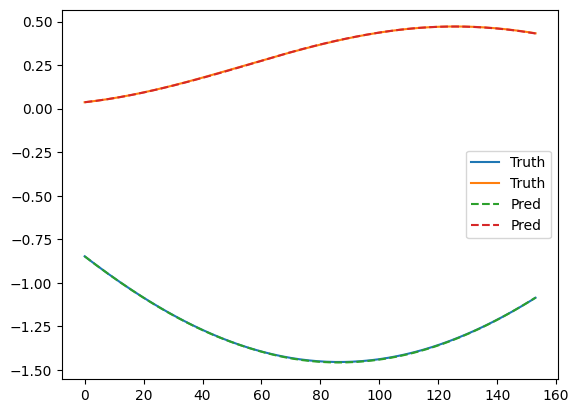



ID: d2564c5c6d54446d9e3ad04886d71210
mlflow_experiment_name                               2024_11_27_training_00h_04m
seed                                                                           1
data_normaliser_name                                             standard_normal
model_name                                                                  ndde
model_params_activation                                                     relu
model_params_delay_exponential_dist_param                                    5.0
model_params_depth                                                             2
model_params_dropout                                                           0
model_params_final_activation                                           identity
model_params_width_size                                                       64
trainer_name                                                                ndde
trainer_params_bool_discretize_then_optimize                          

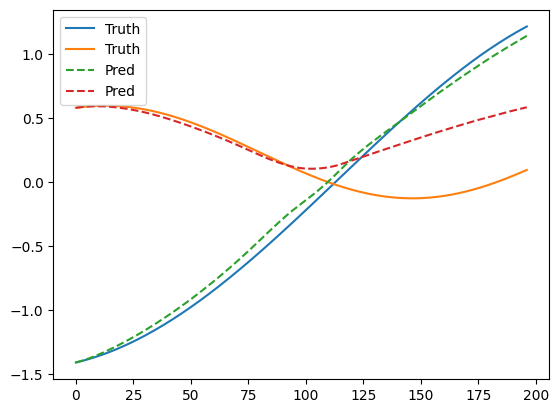

In [11]:
# For each id experiment plot the configuration of the experiment

from IPython.display import Image


list_id_hash_filtered = list(df_training_dataset_merged.index)

for name_id in list_id_hash_filtered:
    print(f"ID: {name_id}")
    print(df_training_dataset_merged.loc[name_id].to_string())
    Image(
        f"{path_xp}/{name_id}/generated_data/trainer_data/ode_trainer/last_test_pred_batch0.png"
    )

    print("\n")